Read Dataset dan informasi

In [2]:
import pandas as pd 

df = pd.read_csv('train.csv')

df.info()

print("=====================")

df['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 3771 entries, 0 to 3770
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  3771 non-null   str  
 1   label     3771 non-null   str  
dtypes: str(2)
memory usage: 59.1 KB


label
jawi       781
jawa       703
sunda      673
lampung    505
lontara    404
bali       396
pegon      309
Name: count, dtype: int64

Melihat dan membaca gambar di dalam dataset

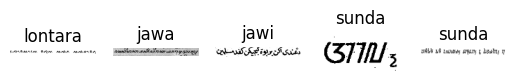

In [3]:
import cv2
import matplotlib.pyplot as plt

for i, row in df.head(5).iterrows():
    img_path = f"images/train/{row['image_id']}" 
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Ubah Label Teks ke Angka
le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])

# Simpan jumlah kelas
num_classes = len(le.classes_)

# 2. Split Data (80% Train, 20% Validation)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_idx'])

In [5]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

# Define Transformasi (Resize gambar agar seragam)
transform_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(10), # Augmentasi ringan
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class AksaraDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id']
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        label = self.df.loc[idx, 'label_idx']
        return image, torch.tensor(label, dtype=torch.long)

# Buat DataLoader
train_dataset = AksaraDataset(train_df, 'images/train', transform=transform_train)
val_dataset = AksaraDataset(val_df, 'images/train', transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [6]:
import torchvision.models as models
import torch.nn as nn

# Load model dan ubah output layer sesuai jumlah aksara
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [7]:
train_dataset = AksaraDataset(train_df, 'images/train', transform=transform_train)
val_dataset = AksaraDataset(val_df, 'images/train', transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [8]:
import pandas as pd
import torch
import os
from PIL import Image

# 1. Load data test / sample submission
test_df = pd.read_csv('test.csv') 
test_df

,image_id
0,WEajVawh.png
1,qA1ZrD98.png
2,G4lDbpor.png
3,fDI0VO86.png
4,J9SshuHf.png
...,...
1215,wKMxEpHX.png
1216,B2HKyGTf.png
1217,WRwiRSHE.png
1218,8H61GdWM.png


In [9]:
# 2. Dataset khusus Data Test (tanpa label)
class TestAksaraDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id']
        img_path = os.path.join(self.img_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=0)
            
        if self.transform:
            image = self.transform(image)
            
        return image

test_dataset = TestAksaraDataset(test_df, 'images/test', transform=transform_val) # Sesuaikan folder test
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Predict menggunakan Model yang Sudah Dilatih
model.eval()
all_preds = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

# 4. Convert Angka ke Teks Label Asli & Save CSV
test_df['label'] = le.inverse_transform(all_preds)
test_df.to_csv('hasil_ai.csv', index=False)